<a href="https://colab.research.google.com/github/Aftab-Raza/A-Post-Quantum-Compliant-Authentication-Scheme-for-IoT-Healthcare-Systems/blob/main/Netflixdataanalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [44]:
df =  pd.read_csv("mymoviedb.csv",lineterminator = "\n")

In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9827 entries, 0 to 9826
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Release_Date       9827 non-null   object 
 1   Title              9827 non-null   object 
 2   Overview           9827 non-null   object 
 3   Popularity         9827 non-null   float64
 4   Vote_Count         9827 non-null   int64  
 5   Vote_Average       9827 non-null   float64
 6   Original_Language  9827 non-null   object 
 7   Genre              9827 non-null   object 
 8   Poster_Url         9827 non-null   object 
dtypes: float64(2), int64(1), object(6)
memory usage: 691.1+ KB


In [46]:
df.duplicated().sum()
df.describe()

,Popularity,Vote_Count,Vote_Average
count,9827.000000,9827.000000,9827.000000
mean,40.326088,1392.805536,6.439534
std,108.873998,2611.206907,1.129759
min,13.354000,0.000000,0.000000
25%,16.128500,146.000000,5.900000
50%,21.199000,444.000000,6.500000
75%,35.191500,1376.000000,7.100000
max,5083.954000,31077.000000,10.000000


In [47]:
#changing the release data formate from object to date time
df["Release_Date"] = pd.to_datetime(df["Release_Date"])
df.info()
df["Release_Date"] = df["Release_Date"].dt.year

df["Release_Date"].dtypes

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9827 entries, 0 to 9826
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Release_Date       9827 non-null   datetime64[ns]
 1   Title              9827 non-null   object        
 2   Overview           9827 non-null   object        
 3   Popularity         9827 non-null   float64       
 4   Vote_Count         9827 non-null   int64         
 5   Vote_Average       9827 non-null   float64       
 6   Original_Language  9827 non-null   object        
 7   Genre              9827 non-null   object        
 8   Poster_Url         9827 non-null   object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(5)
memory usage: 691.1+ KB


dtype('int32')

In [48]:
#Droping the columns
cols = ["Overview","Original_Language" , "Poster_Url"]
df.drop(cols, axis = 1,inplace=True)
df.columns

Index(['Release_Date', 'Title', 'Popularity', 'Vote_Count', 'Vote_Average',
       'Genre'],
      dtype='object')

In [49]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,8.3,"Action, Adventure, Science Fiction"
1,2022,The Batman,3827.658,1151,8.1,"Crime, Mystery, Thriller"
2,2022,No Exit,2618.087,122,6.3,Thriller
3,2021,Encanto,2402.201,5076,7.7,"Animation, Comedy, Family, Fantasy"
4,2021,The King's Man,1895.511,1793,7.0,"Action, Adventure, Thriller, War"


It seems the 'Release_Date' column was not processed correctly in the previous steps, resulting in all '1970' values. I will reload the DataFrame from the CSV to get the original date strings and then properly convert them to extract the year.

In [50]:
# Reload the DataFrame to get the original 'Release_Date' column
df = pd.read_csv("mymoviedb.csv", lineterminator = "\n")

# Display the info and head of the 'Release_Date' column to verify its original state
print("Original 'Release_Date' column info:")
df['Release_Date'].info()
print("\nOriginal 'Release_Date' head:")
display(df['Release_Date'].head())

Original 'Release_Date' column info:
<class 'pandas.core.series.Series'>
RangeIndex: 9827 entries, 0 to 9826
Series name: Release_Date
Non-Null Count  Dtype 
--------------  ----- 
9827 non-null   object
dtypes: object(1)
memory usage: 76.9+ KB

Original 'Release_Date' head:


,Release_Date
0,2021-12-15
1,2022-03-01
2,2022-02-25
3,2021-11-24
4,2021-12-22


Now I will convert the `Release_Date` column to datetime objects, handle potential errors, and then extract only the year.

In [51]:
# Convert 'Release_Date' to datetime, coercing errors to NaT
df['Release_Date'] = pd.to_datetime(df['Release_Date'], errors='coerce')

# Extract the year from the 'Release_Date'
df['Release_Date'] = df['Release_Date'].dt.year

# Display the updated DataFrame info and head to confirm the change
print("Updated DataFrame info:")
df.info()
print("\nUpdated 'Release_Date' head:")
display(df.head())

Updated DataFrame info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9827 entries, 0 to 9826
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Release_Date       9827 non-null   int32  
 1   Title              9827 non-null   object 
 2   Overview           9827 non-null   object 
 3   Popularity         9827 non-null   float64
 4   Vote_Count         9827 non-null   int64  
 5   Vote_Average       9827 non-null   float64
 6   Original_Language  9827 non-null   object 
 7   Genre              9827 non-null   object 
 8   Poster_Url         9827 non-null   object 
dtypes: float64(2), int32(1), int64(1), object(5)
memory usage: 652.7+ KB

Updated 'Release_Date' head:


,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,2021,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...


In [52]:
cols = ["Overview","Original_Language","Poster_Url"]
df.drop(cols,axis=1,inplace=True)
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,8.3,"Action, Adventure, Science Fiction"
1,2022,The Batman,3827.658,1151,8.1,"Crime, Mystery, Thriller"
2,2022,No Exit,2618.087,122,6.3,Thriller
3,2021,Encanto,2402.201,5076,7.7,"Animation, Comedy, Family, Fantasy"
4,2021,The King's Man,1895.511,1793,7.0,"Action, Adventure, Thriller, War"


In [53]:
conditions = [
    (df['Vote_Average'] > 8),
    (df['Vote_Average'] >= 7) & (df['Vote_Average'] <= 8),
    (df['Vote_Average'] >= 5) & (df['Vote_Average'] < 7),
    (df['Vote_Average'] < 5)
]

labels = ['Popular', 'Average', 'Below Average', 'Poor']

df['Vote_Average'] = np.select(conditions, labels, default='Unknown')

display(df.head())
df.info()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,Popular,"Action, Adventure, Science Fiction"
1,2022,The Batman,3827.658,1151,Popular,"Crime, Mystery, Thriller"
2,2022,No Exit,2618.087,122,Below Average,Thriller
3,2021,Encanto,2402.201,5076,Average,"Animation, Comedy, Family, Fantasy"
4,2021,The King's Man,1895.511,1793,Average,"Action, Adventure, Thriller, War"


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9827 entries, 0 to 9826
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Release_Date  9827 non-null   int32  
 1   Title         9827 non-null   object 
 2   Popularity    9827 non-null   float64
 3   Vote_Count    9827 non-null   int64  
 4   Vote_Average  9827 non-null   object 
 5   Genre         9827 non-null   object 
dtypes: float64(1), int32(1), int64(1), object(3)
memory usage: 422.4+ KB


In [54]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,Popular,"Action, Adventure, Science Fiction"
1,2022,The Batman,3827.658,1151,Popular,"Crime, Mystery, Thriller"
2,2022,No Exit,2618.087,122,Below Average,Thriller
3,2021,Encanto,2402.201,5076,Average,"Animation, Comedy, Family, Fantasy"
4,2021,The King's Man,1895.511,1793,Average,"Action, Adventure, Thriller, War"


In [55]:
df["Vote_Average"].value_counts()

,count
Vote_Average,
Below Average,6007
Average,2913
Poor,593
Popular,314


In [56]:
df.dropna(inplace=True)
df.isna().sum()

,0
Release_Date,0
Title,0
Popularity,0
Vote_Count,0
Vote_Average,0
Genre,0


In [57]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,Popular,"Action, Adventure, Science Fiction"
1,2022,The Batman,3827.658,1151,Popular,"Crime, Mystery, Thriller"
2,2022,No Exit,2618.087,122,Below Average,Thriller
3,2021,Encanto,2402.201,5076,Average,"Animation, Comedy, Family, Fantasy"
4,2021,The King's Man,1895.511,1793,Average,"Action, Adventure, Thriller, War"


In [65]:
df["Genre"] = df["Genre"].str.split(',')
df = df.explode("Genre").reset_index(drop=True)
df['Genre'] = df['Genre'].str.strip()
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,Popular,Action
1,2021,Spider-Man: No Way Home,5083.954,8940,Popular,Adventure
2,2021,Spider-Man: No Way Home,5083.954,8940,Popular,Science Fiction
3,2022,The Batman,3827.658,1151,Popular,Crime
4,2022,The Batman,3827.658,1151,Popular,Mystery


In [60]:
sns.set_style("whitegrid")


In [62]:
df['Genre'].describe()


,Genre
count,25793
unique,38
top,Thriller
freq,1973


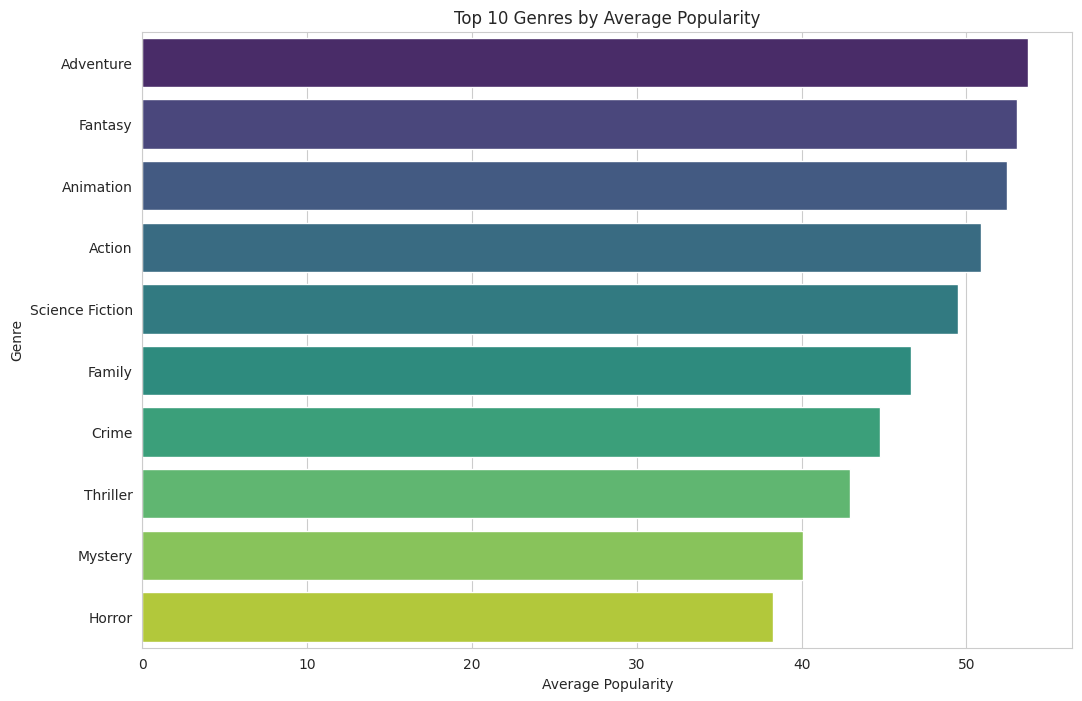

In [68]:
genre_popularity = df.groupby('Genre')['Popularity'].mean().sort_values(ascending=False).head(10)

fig = plt.figure(figsize=(12, 8))
sns.barplot(x=genre_popularity.values, y=genre_popularity.index, palette='viridis', hue=genre_popularity.index, legend=False)
plt.title('Top 10 Genres by Average Popularity')
plt.xlabel('Average Popularity')
plt.ylabel('Genre')
plt.show()

**what movie have the highest popularity**

In [70]:
highest_popularity_movie = df.loc[df['Popularity'].idxmax()]
print(f"Movie with the highest popularity: {highest_popularity_movie['Title']} (Popularity: {highest_popularity_movie['Popularity']})")

Movie with the highest popularity: Spider-Man: No Way Home (Popularity: 5083.954)
